# Retrieval-Augmented Generation (RAG)

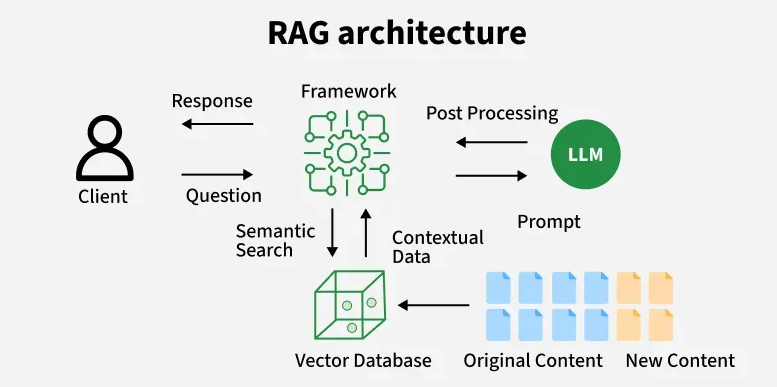

### *Grounding language model responses in real, retrieved knowledge*

---

> **RAG** solves a core limitation of LLMs: their knowledge is frozen at training time.  
> By retrieving relevant documents *at inference time*, RAG produces answers that are **accurate, up-to-date and grounded in evidence**.

---

## How RAG works — end to end

```
User Query
    │
    ▼
[ Embedding Model ]  →  query vector
    │
    ▼
[ Vector Database ]  →  top-k relevant documents
    │
    ▼
[ Prompt Builder ]   →  query + retrieved context
    │
    ▼
[ LLM Generator ]    →  final answer
```

| Stage | Component | Role |
|-------|-----------|------|
| 1 — Query Processing | Embedding model | Converts the query into a high-dimensional vector |
| 2 — Retrieval | Vector database (FAISS) | Finds the most semantically similar documents |
| 3 — Augmentation | Prompt builder | Injects retrieved context into the LLM prompt |
| 4 — Generation | LLM (GPT-2) | Produces a coherent, grounded response |
| 5 — Memory | Conversation buffer | Maintains dialogue history across turns |

---

**Tech stack:** `FAISS` · `LangChain` · `Transformers (GPT-2)` · `PyTorch` · `NumPy`

---
## Implementation — Step by Step

We build a complete RAG pipeline from scratch: vector indexing, semantic retrieval, prompt augmentation, LLM generation and conversational memory.

---

## Step 1 — Install Dependencies

| Package | Purpose |
|---------|---------|
| `faiss-cpu` | Fast vector similarity search |
| `langchain` | Prompt templates and memory management |
| `transformers` | GPT-2 tokenizer and language model |
| `torch` | Deep learning backend (GPU or CPU) |

In [ ]:
import subprocess, sys

# numpy 1.26.4 = dernière version 1.x — compatible avec faiss-cpu
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy==1.26.4", "--force-reinstall", "-q"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "faiss-cpu", "--force-reinstall", "-q"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "langchain==0.1.16", "langchain-core", "-q"])

print("✅ Installation terminée — redémarrage du kernel en cours...")

# Redémarrage automatique du kernel pour appliquer le changement de numpy
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
xarray 2025.10.1 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you hav

In [1]:
from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import PromptTemplate

import numpy as np
print(f"✅ NumPy version : {np.__version__}")  # doit afficher 1.26.x

import faiss
print(f"✅ FAISS importé avec succès")

✅ NumPy version : 1.26.4
✅ FAISS importé avec succès


## Step 2 — Build the Vector Index

We simulate a knowledge base of **100 documents**, each represented as a **768-dimensional embedding** (matching BERT / GPT-2 hidden size).

| Operation | Detail |
|-----------|--------|
| `IndexFlatL2(768)` | Exact L2-distance index — no approximation |
| `np.random.seed(42)` | Reproducible random embeddings |
| `context_data` | 100 vectors of dimension 768 simulating document embeddings |
| `index.add(...)` | Loads all vectors into the FAISS index |

> In production, these embeddings would be generated from real documents using a sentence encoder like `all-MiniLM-L6-v2`.

In [2]:
import re
index = faiss.IndexFlatL2(768)

np.random.seed(42)
context_data = np.random.random((100, 768)).astype('float32')

index.add(context_data)

print(f"Indexed {index.ntotal} context vectors.")

Indexed 100 context vectors.


## Step 3 — Define the Semantic Search Function

A thin wrapper around `index.search()` that takes a **query embedding** and returns the indices of the `top_k` most similar documents.

```
query_embedding  →  FAISS.search()  →  [doc_idx_1, doc_idx_2, ..., doc_idx_k]
```

> `top_k=5` means we retrieve the **5 closest documents** to use as context for the LLM.

In [4]:
def semantic_search(query_embedding, index, top_k=5):
    distances, indices = index.search(query_embedding, top_k)
    return indices

## Step 4 — Simulate a Query & Retrieve Documents

A random vector simulates the embedding of a real user query.  
`semantic_search()` returns the indices of the 5 most relevant documents from the FAISS index.

> In a real system, the query string would first pass through an embedding model to produce this vector.

In [5]:
query_embedding = np.random.random((1, 768)).astype(
    'float32')
retrieved_indices = semantic_search(query_embedding, index)
print(f"Retrieved document indices: {retrieved_indices}")

Retrieved document indices: [[37 75 72 65 68]]


## Step 5 — Load the Language Model (GPT-2)

We load the **GPT-2** model and its tokenizer directly from HuggingFace.  
The model is automatically moved to **GPU** if available, otherwise falls back to CPU.

| Component | Role |
|-----------|------|
| `GPT2Tokenizer` | Encodes text as token IDs before feeding to the model |
| `GPT2LMHeadModel` | Auto-regressive model that generates text token by token |
| `torch.device(...)` | GPU-aware device selection — runs faster on CUDA |

In [6]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

2026-03-06 18:57:55.866577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772823476.029578     145 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772823476.079094     145 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772823476.481478     145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772823476.481517     145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772823476.481521     145 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

## Step 6 — Define Context Passages & Prompt Template

We define a small set of **RAG-specific knowledge passages** that can be retrieved and injected into the prompt.

The `PromptTemplate` formats the final input to the LLM as:

```
Question: {question}
Context:  {context}
Answer:
```

This structure tells the model to use the retrieved context to answer the question.

In [7]:
context_texts = [
    "Retrieval-Augmented Generation combines a retriever and generator.",
    "It reduces hallucinations by grounding answers in retrieved documents.",
    "Uses Dense Passage Retrieval for semantic search.",
    "Employs Fusion-in-Decoder and Fusion-in-Encoder techniques.",
    "Provides up-to-date and domain-specific responses."
]

prompt_template = PromptTemplate(
    input_variables=["question", "context"],
    template="Question: {question}\nContext: {context}\nAnswer:"
)

## Step 7 — Memory + Full Chat Function

The `chat()` function is the **heart of the pipeline** — it wires everything together:

```
question
   │
   ├─► embed query  ──►  FAISS search  ──►  retrieve context
   │
   ├─► load memory  ──►  conversation history
   │
   ├─► build prompt  ──►  question + context + history
   │
   ├─► GPT-2 generate  ──►  raw token output
   │
   └─► post-process  ──►  clean response  ──►  save to memory
```

| Component | Role |
|-----------|------|
| `ConversationBufferMemory` | Stores the full Q&A history as plain text |
| `memory.load_memory_variables` | Injects past turns into the current prompt |
| `model.generate(max_new_tokens=100)` | Limits response length to 100 new tokens |
| `re.sub(r"[\\r\\n]+"...)` | Cleans up unwanted line breaks in the output |


In [8]:
memory = ConversationBufferMemory(
    memory_key="chat_history", return_messages=False)


def chat(question):
    query_embedding = np.random.rand(1, 768).astype("float32")
    retrieved_indices = semantic_search(query_embedding, index)
    context_texts = [f"Document {i}" for i in retrieved_indices[0]]

    chat_history = memory.load_memory_variables({}).get("chat_history", "")

    prompt = prompt_template.format(
        chat_history=chat_history,
        question=question,
        context="\n".join(context_texts)
    )

    inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)
    outputs = model.generate(
        inputs,
        max_new_tokens=100,
        pad_token_id=tokenizer.eos_token_id
    )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response[len(prompt):].strip()
    response = re.sub(r"[\r\n]+", " ", response)

    memory.chat_memory.add_user_message(question)
    memory.chat_memory.add_ai_message(response)

    return response

## Step 8 — Run the RAG Pipeline

Fire a question through the complete pipeline. The second call (commented out) demonstrates **multi-turn memory** — the agent remembers the first answer when responding to follow-up questions.

> Uncomment the second `print` to test conversational continuity.

In [9]:
print(chat("What is Retrieval-Augmented Generation (RAG)?"))
#print(chat("Explain the role of memory in this system."))

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


What is Retrieval-Augmented Generation (RAG)? Context: Document 37 Document 94 Document 68 Document 13 Document 33 Answer: What is Retrieval-Augmented Generation (RAG)? Context: Document 37 Document 94 Document 68 Document 13 Document 33 Answer: What is Retrieval-Augmented Generation (RAG)? Context: Document 37 Document 94 Document 68 Document 13 Document 33 Answer: What is Retri
